# IPCA – Grupos (IBGE/SIDRA 7060)

Este notebook apresenta:

**1. O que são os grupos do IPCA**  
**2. Como o IBGE organiza a tabela 7060**  
**3. Execução do pipeline `ipca_grupos`**  
**4. Consulta ao banco de dados (`bcb.ipca_grupos`)**  
**5. Gráficos e análises exploratórias por grupo**  

Vamos começar entendendo o conceito.

# 1. O que são os grupos do IPCA?

O **IPCA (Índice Nacional de Preços ao Consumidor Amplo)** é estruturado em:

- **grupos (nível 1)**  
- subgrupos (nível 2)  
- itens (nível 4)  
- subitens (nível 7)  

Os **grupos** representam categorias amplas de consumo, como:

- Alimentação no domicílio  
- Habitação  
- Transportes  
- Saúde e cuidados pessoais  

Trabalhar com grupos permite:

- análises macro da inflação  
- identificação de pressões setoriais  
- decomposição do IPCA em blocos principais

# 2. Tabela 7060 – IPCA por grupos

A tabela 7060 do SIDRA traz o IPCA por:

- Brasil (nível nacional)  
- grandes grupos, grupos, itens e subitens  

As variáveis que usamos aqui são:

- **63** → variação mensal (%), chamada `indice`  
- **66** → peso do grupo no índice, chamada `peso`  

Nosso pipeline monta a tabela `bcb.ipca_grupos` com:

- `date`  
- `indice`  
- `peso`  
- `category` (código numérico de 2 dígitos)  
- `category_name` (descrição do grupo)

# 3. Ajustar o PYTHONPATH para importar `src/`

In [43]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 4. Importações

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.ipca_grupos import run_ipca_grupos
from src.database.connection import engine

pd.set_option("display.float_format", "{:.6f}".format)

# 5. Executar pipeline IPCA grupos (IBGE – tabela 7060)

Isso irá:
- consultar a tabela 7060 do SIDRA  
- baixar as variáveis 63 (Indice) e 66 (Peso)  
- filtrar apenas grupos (nível 2)  
- criar/atualizar a tabela `bcb.ipca_grupos`  
- inserir todos os dados no PostgreSQL

In [45]:
run_ipca_grupos()

2026-04-20 20:51:00,402 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=63, periodo=all
2026-04-20 20:51:03,413 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.
2026-04-20 20:51:03,428 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=66, periodo=all
2026-04-20 20:51:05,378 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.


Tabela bcb.ipca_grupos atualizada com sucesso!


,date,indice,peso,category,category_name
0,2020-01-01,0.390000,19.348300,1,Alimentação e bebidas
1,2020-01-01,0.550000,15.594500,2,Habitação
2,2020-01-01,-0.070000,3.752900,3,Artigos de residência
3,2020-01-01,-0.480000,4.577000,4,Vestuário
4,2020-01-01,0.320000,20.597900,5,Transportes
...,...,...,...,...,...
670,2026-03-01,1.640000,20.451600,5,Transportes
671,2026-03-01,0.420000,13.662100,6,Saúde e cuidados pessoais
672,2026-03-01,0.650000,10.289100,7,Despesas pessoais
673,2026-03-01,0.020000,6.303500,8,Educação


# 6. Verificar tabelas existentes no schema `bcb`

In [46]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,ipca_grupos
2,ipca_itens
3,ipca_subgrupos
4,ipca_subitens
5,selic_meta
6,selic_over


# 7. Carregar dados de IPCA grupos

In [49]:
query_grupos = """
select *
from bcb.ipca_grupos
order by date desc, category;
"""

df = pd.read_sql(query_grupos, engine)
df.head(10)

,date,indice,peso,category,category_name
0,2026-03-01,1.560000,21.309500,1,Alimentação e bebidas
1,2026-03-01,0.220000,15.298900,2,Habitação
2,2026-03-01,0.510000,3.478900,3,Artigos de residência
3,2026-03-01,0.460000,4.654600,4,Vestuário
4,2026-03-01,1.640000,20.451600,5,Transportes
5,2026-03-01,0.420000,13.662100,6,Saúde e cuidados pessoais
6,2026-03-01,0.650000,10.289100,7,Despesas pessoais
7,2026-03-01,0.020000,6.303500,8,Educação
8,2026-03-01,0.190000,4.551800,9,Comunicação
9,2026-02-01,0.260000,21.401400,1,Alimentação e bebidas


# 8. Primeiros registros

In [50]:
df.tail(10)

,date,indice,peso,category,category_name
665,2020-02-01,0.210000,5.709600,9,Comunicação
666,2020-01-01,0.390000,19.348300,1,Alimentação e bebidas
667,2020-01-01,0.550000,15.594500,2,Habitação
668,2020-01-01,-0.070000,3.752900,3,Artigos de residência
669,2020-01-01,-0.480000,4.577000,4,Vestuário
670,2020-01-01,0.320000,20.597900,5,Transportes
671,2020-01-01,-0.320000,13.533400,6,Saúde e cuidados pessoais
672,2020-01-01,0.350000,10.733000,7,Despesas pessoais
673,2020-01-01,0.160000,6.148500,8,Educação
674,2020-01-01,0.120000,5.714600,9,Comunicação


# 9. Estatísticas básicas

In [51]:
df.describe()

,date,indice,peso
count,675,675.000000,675.000000
mean,2023-01-30 22:43:12,0.433896,11.111109
min,2020-01-01 00:00:00,-4.510000,3.478900
25%,2021-07-01 00:00:00,0.040000,4.785900
50%,2023-02-01 00:00:00,0.360000,10.115300
75%,2024-09-01 00:00:00,0.700000,15.577700
max,2026-03-01 00:00:00,6.280000,22.307100
std,NaN,0.889715,6.476236


# 10. Grupos com maior peso médio

Aqui vemos quais grupos têm maior relevância estrutural no IPCA.

In [52]:
top_peso = (
    df.groupby(["category", "category_name"])["peso"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_peso

,category,category_name,peso
0,1,Alimentação e bebidas,21.151291
1,5,Transportes,20.657075
2,2,Habitação,15.426708
3,6,Saúde e cuidados pessoais,13.217584
4,7,Despesas pessoais,10.181111
5,8,Educação,5.952411
6,9,Comunicação,5.075415
7,4,Vestuário,4.569220
8,3,Artigos de residência,3.769172


# 11. Evolução da variação mensal de um grupo específico

Vamos escolher um grupo de interesse (por exemplo, alimentação) e analisar sua trajetória.

In [60]:
filtro = "ab"

grp = df[df["category_name"].str.contains(filtro, case=False, na=False)]

grp.head()

,date,indice,peso,category,category_name
1,2026-03-01,0.220000,15.298900,2,Habitação
10,2026-02-01,0.300000,15.362700,2,Habitação
19,2026-01-01,-0.110000,15.429000,2,Habitação
28,2025-12-01,-0.330000,15.531400,2,Habitação
37,2025-11-01,0.520000,15.478300,2,Habitação


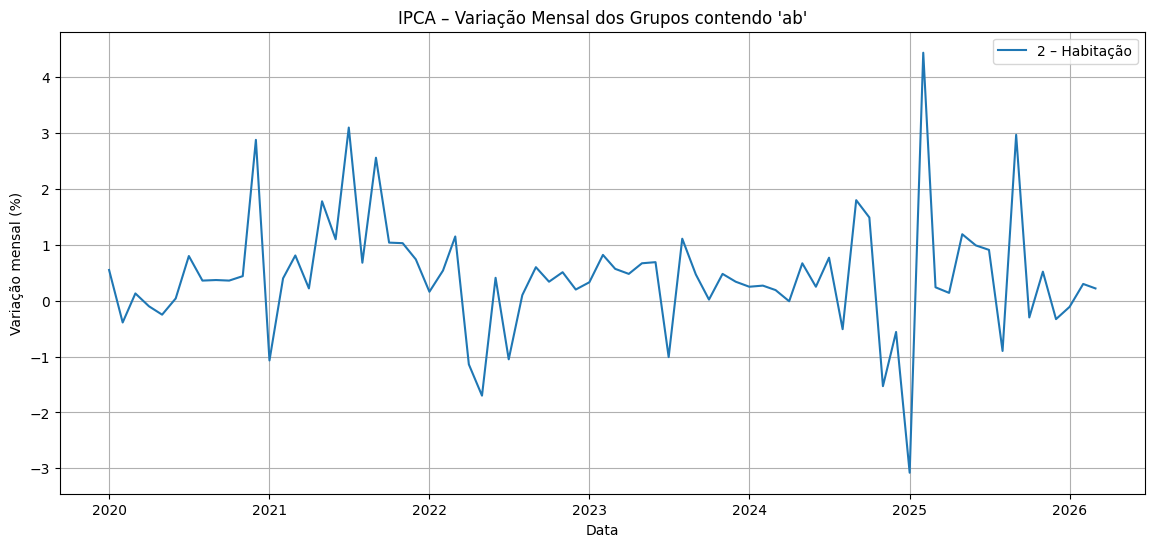

In [61]:
plt.figure(figsize=(14, 6))
for cat, g in grp.groupby("category"):
    plt.plot(g["date"], g["indice"], label=f"{cat} – {g['category_name'].iloc[0]}")

plt.title(f"IPCA – Variação Mensal dos Grupos contendo '{filtro}'")
plt.xlabel("Data")
plt.ylabel("Variação mensal (%)")
plt.grid(True)
plt.legend()
plt.show()

# 12. Heatmap de variação mensal – últimos 12 meses

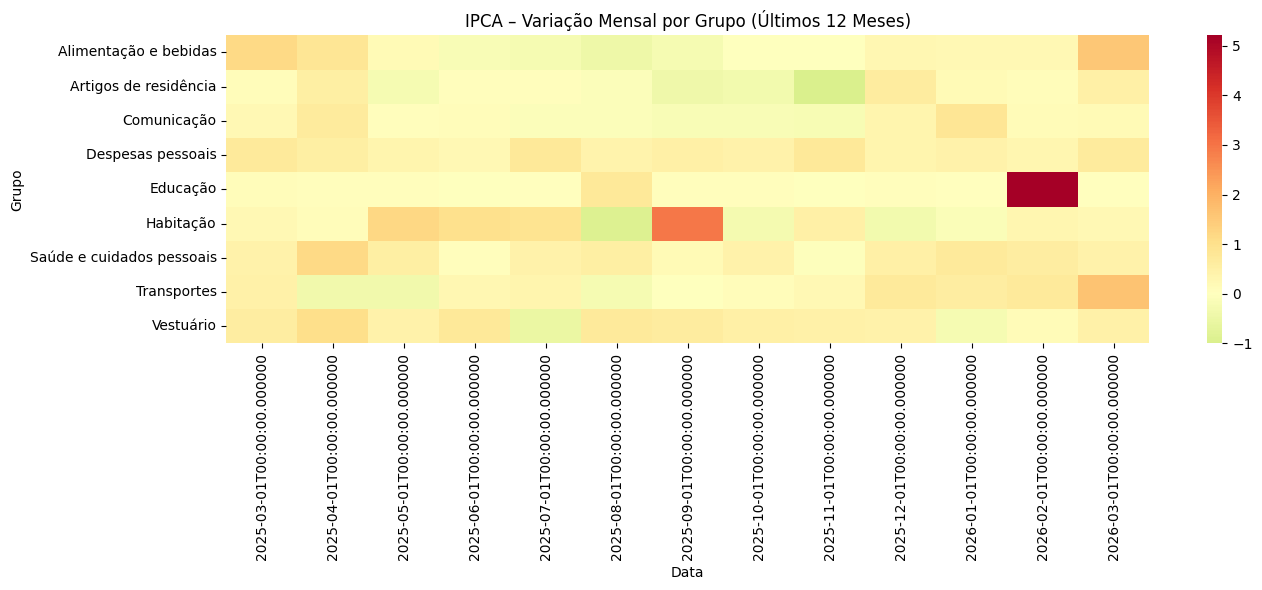

In [62]:
df_recent = df[df["date"] >= df["date"].max() - pd.offsets.DateOffset(months=12)]

pivot_hm = df_recent.pivot_table(
    index="category_name",
    columns="date",
    values="indice"
)

plt.figure(figsize=(14, max(6, len(pivot_hm) * 0.25)))
sns.heatmap(
    pivot_hm,
    cmap="RdYlGn_r",
    center=0,
    annot=False
)
plt.title("IPCA – Variação Mensal por Grupo (Últimos 12 Meses)")
plt.xlabel("Data")
plt.ylabel("Grupo")
plt.tight_layout()
plt.show()

# 13. Distribuição da variação mensal por grupo

Aqui avaliamos a dispersão da inflação entre grupos em um mês recente.

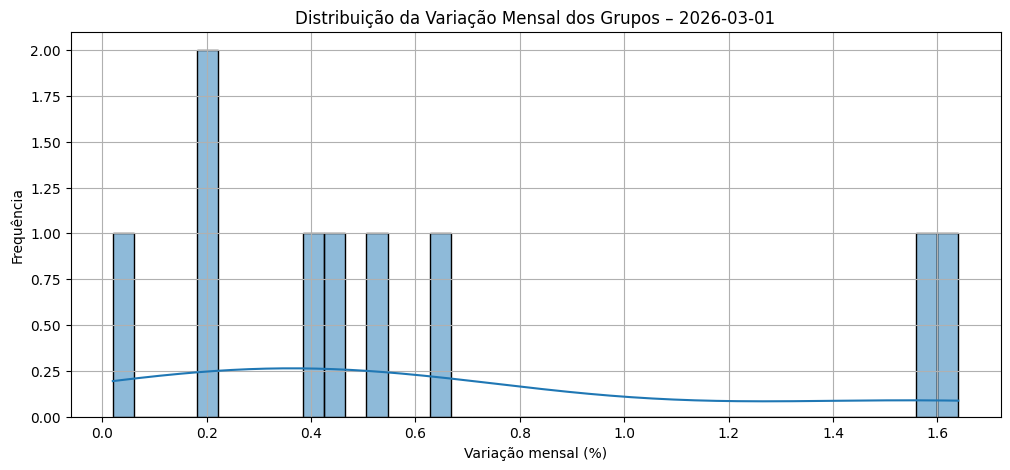

In [63]:
ultimo_mes = df["date"].max()
df_ult = df[df["date"] == ultimo_mes]

plt.figure(figsize=(12, 5))
sns.histplot(df_ult["indice"], bins=40, kde=True)
plt.title(f"Distribuição da Variação Mensal dos Grupos – {ultimo_mes.date()}")
plt.xlabel("Variação mensal (%)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

# 14. Conclusões

- A tabela `bcb.ipca_grupos` traz o IPCA no nível agregado (grupos).  
- As colunas `indice` e `peso` permitem análises de contribuição e relevância de cada grupo.  
- A estrutura `category` (código) + `category_name` (descrição) facilita junções e painéis.  
- Este pipeline é a base para:
  - decomposição da inflação por grupo  
  - análises setoriais  
  - construção de núcleos e medidas alternativas  

Próximos passos:
- Integrar esta tabela com o IPCA geral (`bcb.ipca`)  
- Construir decomposições por grupo, item e subitem  
- Criar dashboards e relatórios automatizados de inflação por grupo